# II. CMB AND NEW PHYSICS

$\Omega_k$ (Spatial Curvature Parameter)

The curvature parameter, $\Omega_k$, modifies the spatial geometry of the universe, which directly affects the angular diameter distance to the surface of last scattering.

$\Omega_k > 0$ (Open Universe): In an open geometry, photon paths diverge, making physical features appear smaller on the sky. Consequently, the acoustic peaks shift toward higher multipoles ($\ell$), corresponding to smaller angular scales.

$\Omega_k < 0$ (Closed Universe): Conversely, in a closed geometry, photon paths converge, making features appear larger on the sky. This shifts the acoustic peaks toward lower multipoles ($\ell$), corresponding to larger angular scales.

Furthermore, spatial curvature alters the evolution of gravitational potentials at late times. This heavily modifies the Late Integrated Sachs-Wolfe (lISW) effect, significantly impacting the amplitude of the power spectrum at the lowest multipoles ($\ell \lesssim 20$).

In [1]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import camb
from camb.symbolic import  *
import pandas as pd

In [3]:
pars = camb.read_ini('https://raw.githubusercontent.com/cmbant/CAMB/master/inifiles/planck_2018.ini')

In [4]:
results = camb.get_results(pars)

# Computing the CMB power spectrum

powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
totCL=powers['total'] # Total CMB power spectrum


(2601, 4)


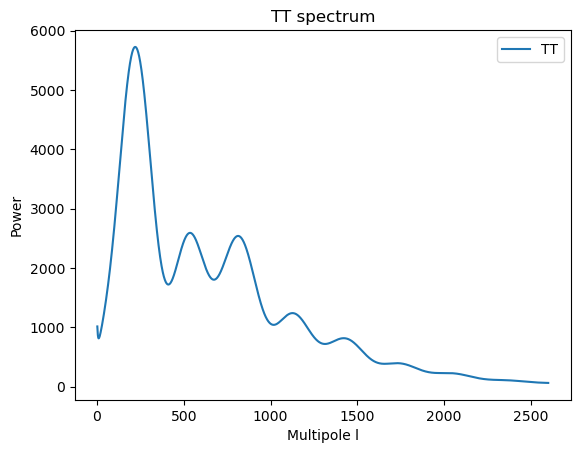

In [6]:
# Plotting the power spectrum of the Total Temperature (TT)

totCL = powers['total']
print(totCL.shape)
# Python CL arrays are all at zero basis (including L=0)
ls = np.arange(totCL.shape[0])
plt.plot(ls[2:], totCL[2:, 0], label='TT')
plt.title('TT spectrum')
plt.xlabel('Multipole l')
plt.ylabel('Power')
plt.legend()
plt.show()

In [7]:
# Changing the cosmological parameters to see the effect on the CMB power spectrum


omega_k_pars_plus = pars.copy() # Copy the standard parameters
omega_k_pars_minus = pars.copy() # Copy the standard parameters

omega_k_pars_plus.omk += 0.01
omega_k_pars_minus.omk += -0.01

In [8]:
# Computing results for this parameter

omega_k_results_plus = camb.get_results(omega_k_pars_plus)
omega_k_results_minus = camb.get_results(omega_k_pars_minus)

# Computing the CMB power spectrum for the modified parameters

var_powers_plus = omega_k_results_plus.get_cmb_power_spectra(omega_k_pars_plus, CMB_unit='muK')
var_powers_minus = omega_k_results_minus.get_cmb_power_spectra(omega_k_pars_minus, CMB_unit='muK')

# Getting the total CMB power spectrum

var_totCL_plus = var_powers_plus['total']
var_totCL_minus = var_powers_minus['total']

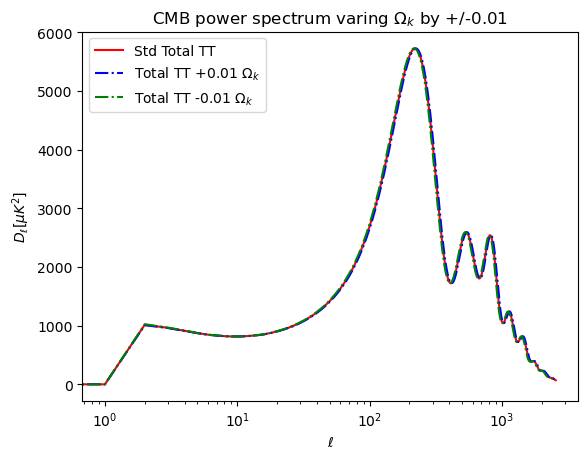

In [9]:
# Plotting the CMB spectrum
min_len = min(len(totCL), len(var_totCL_plus), len(var_totCL_minus))

plt.figure()
plt.plot(ls[:min_len],totCL[:min_len,0], color='r', label='Std Total TT') # Taking from l=2 since l=0,1 are not physical
plt.plot(ls[:min_len],var_totCL_plus[:min_len,0], color='b',ls = '-.',label=r'Total TT +0.01 $\Omega_k$')
plt.plot(ls[:min_len],var_totCL_minus[:min_len,0], color='g',ls = '-.',label=r'Total TT -0.01 $\Omega_k$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title(r'CMB power spectrum varing $\Omega_k$ by +/-0.01')
plt.show()

In [10]:
monopole_source, ISW, doppler, quadrupole_service = camb.symbolic.get_scalar_temperature_sources()

In [11]:
early_ISW = sympy.Piecewise( (ISW, 1/a-1> 30),(0, True))  #redshift > 30
late_ISW = ISW - early_ISW

In [12]:
names = ['mon','ISW','eISW','LISW','dop', 'Q']
pars.set_custom_scalar_sources([monopole_source, ISW,early_ISW, late_ISW,doppler,quadrupole_service],
        source_names =names)

data = camb.get_results(pars)
dic  = data.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

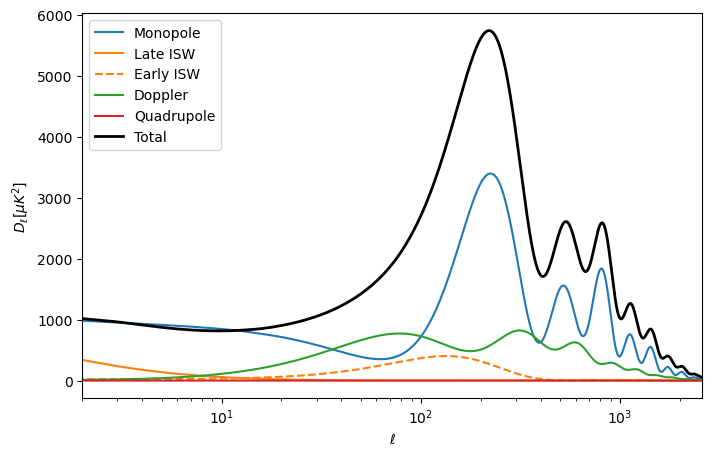

In [13]:
ls_TT =np.arange(dic['TxT'].shape[0])
plt.figure(figsize=(8,5))
plt.semilogx(ls_TT,dic['monxmon'], color='C0')
plt.semilogx(ls_TT,dic['LISWxLISW'], color='C1')
plt.semilogx(ls_TT,dic['eISWxeISW'], ls='--', color='C1')
plt.semilogx(ls_TT,dic['dopxdop'],color='C2')
plt.semilogx(ls_TT,dic['QxQ'], color='C3')
plt.semilogx(ls_TT,dic['TxT'], lw=2, color='k')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.xlim(2, ls[-1])
plt.legend(['Monopole','Late ISW','Early ISW','Doppler','Quadrupole', 'Total'], loc = 'upper left');

... Don't know if it's right...

In [ ]:
#omega_k_pars_minus.set_custom_scalar_sources([monopolo_fonte, ISW,doppler,quadrupole_service],
 #       source_names =names)
#omega_k_pars_plus.set_custom_scalar_sources([monopolo_fonte, ISW,doppler,quadrupole_service],
  #      source_names =names)

#omega_k_data_plus = camb.get_results(omega_k_pars_plus)
#omega_k_data_minus = camb.get_results(omega_k_pars_minus)

#omega_k_dic_plus = omega_k_data_plus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')
#omega_k_dic_minus = omega_k_data_minus.get_cmb_unlensed_scalar_array_dict(CMB_unit='muK')

# grafico in una griglia di grafici, monopolo, dipolo ,ISW e quadrupolo

# Subplot per monopolo
#plt.subplots(2, 2, figsize=(10, 10))
#plt.suptitle('Effects of varying As by +/-0.01')
#plt.subplot(221)
#plt.semilogx(ls_TT,dic['monxmon'], color='r')
#plt.semilogx(ls_TT,omega_k_dic_plus['monxmon'], color='b',ls = '-.')
#plt.semilogx(ls_TT,omega_k_dic_minus['monxmon'], color='g',ls = '-.')
#plt.xlabel('$\ell$')
#plt.ylabel(r'$D_{\ell} [\mu K^2]$')
#plt.xlim(2, ls[-1])
#plt.legend(['Monopole','Monopole +0.01 $\Omega_k$','Monopole -0.01 $\Omega_k$'], loc = 'upper left')
#plt.title('Monopole')

# Subplot per effetto ISW
#plt.subplot(222)
#plt.semilogx(ls_TT,dic['LISWxLISW'], color='r', ls = '-')
#plt.semilogx(ls_TT,dic['ISWxISW'], color='r', ls = '--')
#plt.semilogx(ls_TT,omega_k_dic_plus['ISWxISW'], color='b',ls = '-')
#plt.semilogx(ls_TT,omega_k_dic_minus['ISWxISW'], color='g',ls = '-')
#plt.semilogx(ls_TT,omega_k_dic_plus['LISWxLISW'], color='b',ls = '-')
#plt.semilogx(ls_TT,omega_k_dic_minus['LISWxLISW'], color='g',ls = '-')
#plt.semilogx(ls_TT,dic['eISWxeISW'], ls=':', color='r')
#plt.semilogx(ls_TT,omega_k_dic_plus['eISWxeISW'], ls=':', color='b')
#plt.semilogx(ls_TT,omega_k_dic_minus['eISWxeISW'], ls=':', color='g')
#plt.xlabel('$\ell$')
#plt.ylabel(r'$D_{\ell} [\mu K^2]$')
#plt.xlim(2, ls[-1])
#plt.legend(['Late ISW','Late ISW +0.01 $\Omega_k$','Late ISW -0.01 $\Omega_k$','Early ISW','Early ISW +0.01 $\Omega_k$','Early ISW -0.01 $\Omega_k$'], loc = 'upper left')
#plt.title('ISW effects')

# Subplot per effetto dipolo
#plt.subplot(223)
#plt.semilogx(ls_TT,dic['dopxdop'],color='r')
#plt.semilogx(ls_TT,omega_k_dic_plus['dopxdop'],color='b',ls = '-.')
#plt.semilogx(ls_TT,omega_k_dic_minus['dopxdop'],color='g',ls = '-.')
#plt.xlabel('$\ell$')
#plt.ylabel(r'$D_{\ell} [\mu K^2]$')
#plt.xlim(2, ls[-1])
#plt.legend(['Doppler','Doppler +0.01 $\Omega_k$','Doppler -0.01 $\Omega_k$'], loc = 'upper left')
#plt.title('Doppler effect')

# Subplot per effetto Quadrupolo
#plt.subplot(224)
#plt.semilogx(ls_TT,dic['QxQ'], color='r')
#plt.semilogx(ls_TT,omega_k_dic_plus['QxQ'], color='b',ls = '-.')
#plt.semilogx(ls_TT,omega_k_dic_minus['QxQ'], color='g',ls = '-.')
#plt.xlabel('$\ell$')
#plt.ylabel(r'$D_{\ell} [\mu K^2]$')
#plt.xlim(2, ls[-1])
#plt.legend(['Quadrupole','Quadrupole +0.01 $\Omega_k$','Quadrupole -0.01 $\Omega_k$'], loc = 'upper left')
#plt.title('Quadrupole effect')


In [15]:
# Reading the file with the Planck 2018 data

data = pd.read_csv(
    "COM_PowerSpect_CMB-TT-binned_R3.01.txt",
    sep=r'\s+',
    comment="#",
    names=["ell_eff", "Dl", "err_minus", "err_plus", "bestfit"]
)

print(data.head())

      ell_eff          Dl  err_minus   err_plus     bestfit
0   47.711224  1479.33552  50.765488  50.765488  1461.11304
1   76.471606  2034.96833  54.710158  54.710158  2062.38073
2  105.917385  2955.39416  64.976644  64.976644  2904.52526
3  135.605348  3869.51392  76.914374  76.914374  3902.48963
4  165.405597  4889.46506  86.585626  86.585626  4861.35537


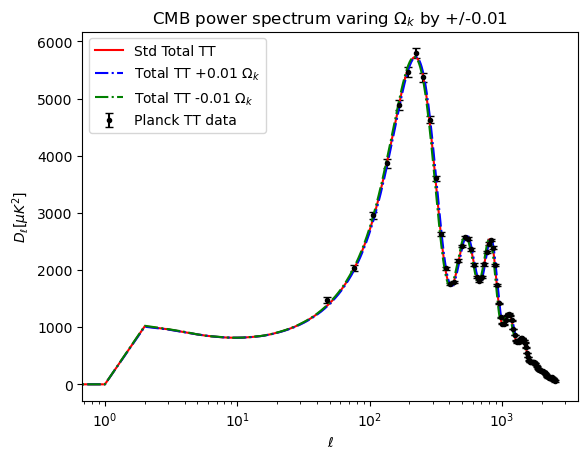

In [17]:
from scipy.interpolate import interp1d
# Adding points to the plot

plt.figure()

# Plotting 'Dl' with error bars

plt.errorbar(data['ell_eff'], data['Dl'],  yerr=[data['err_minus'], data['err_plus']],  fmt='.', color='k', ecolor='k', capsize=3, label='Planck TT data')

plt.plot(ls[:min_len],totCL[:min_len,0], color='r', label='Std Total TT') # Prendendo da l = 2 dato che l=0,1 non sono fisici 
plt.plot(ls[:min_len],var_totCL_plus[:min_len,0], color='b',ls = '-.',label=r'Total TT +0.01 $\Omega_k$')
plt.plot(ls[:min_len],var_totCL_minus[:min_len,0], color='g',ls = '-.',label=r'Total TT -0.01 $\Omega_k$')
plt.legend()
plt.xlabel(r'$\ell$')
plt.xscale('log')
plt.ylabel(r'$D_{\ell} [\mu K^2]$')
plt.title(r'CMB power spectrum varing $\Omega_k$ by +/-0.01')

plt.show()

To compare the theoretical predictions with the Planck observational data, I calculated a simplified $\chi^2$ statistic of the form:

$$\chi^2 = \sum_i \left( \frac{D_{\ell,i}^{\text{theory}} - D_{\ell,i}^{\text{Planck}}}{\sigma_{\ell,i}^{\text{Planck}}} \right)^2 ,$$

where:

- $D_{\ell,i}^{\text{theory}}$ is the theoretical lensed value of the model, expressed in $\mu\text{K}^2$, interpolated exactly at the same effective multipole $\ell_{\mathrm{eff},i}$ measured by Planck;

- $D_{\ell,i}^{\text{Planck}}$ is the corresponding observed value from the binned Planck data;

- $\sigma_{\ell,i}^{\text{Planck}} = \frac{1}{2}(\text{err}^+ + \text{err}^-)$ is the experimental uncertainty, approximated as the mean of the upper and lower errors.

In [18]:
# Creating an array as long as the calculated multipoles and taking the spectrum
ell_std = np.arange(totCL.shape[0])
Dl_std  = totCL[:,0]

# +Ω_k
ell_p = np.arange(var_totCL_plus.shape[0])
Dl_p  = var_totCL_plus[:,0]

# −Ω_k
ell_m = np.arange(var_totCL_minus.shape[0])
Dl_m  = var_totCL_minus[:,0]

# Keep only ell >= 2 (fisically significant)
mask_std = ell_std >= 2
mask_p   = ell_p   >= 2
mask_m   = ell_m   >= 2

# Creating masks for analysis
ell_std = ell_std[mask_std]
Dl_std = Dl_std[mask_std]
ell_p   = ell_p[mask_p]
Dl_p   = Dl_p[mask_p]
ell_m   = ell_m[mask_m]
Dl_m   = Dl_m[mask_m]

In [19]:
# Interpolating the models on the Planck points (ell_eff)

xdata = data['ell_eff'].values.astype(float)
ydata = data['Dl'].values.astype(float)
sigma = 0.5*(data['err_plus'].values + data['err_minus'].values)

# Linear Interpolators (extrapolate per sicurezza ai bordi)
f_std = interp1d(ell_std, Dl_std, kind='linear', fill_value='extrapolate', bounds_error=False)
f_p   = interp1d(ell_p,   Dl_p,   kind='linear', fill_value='extrapolate', bounds_error=False)
f_m   = interp1d(ell_m,   Dl_m,   kind='linear', fill_value='extrapolate', bounds_error=False)

Dl_std_at = f_std(xdata)
Dl_p_at   = f_p(xdata)
Dl_m_at   = f_m(xdata)

In [20]:
# Chi^2
chi2_std = np.sum(((Dl_std_at - ydata)/sigma)**2)
chi2_p   = np.sum(((Dl_p_at   - ydata)/sigma)**2)
chi2_m   = np.sum(((Dl_m_at   - ydata)/sigma)**2)

print("χ² std  :", chi2_std)
print("χ² +Ω_k :", chi2_p,  "   Δχ²(+)= ", chi2_p - chi2_std)
print("χ² −Ω_k :", chi2_m,  "   Δχ²(−)= ", chi2_m - chi2_std)

χ² std  : 80.65248356283105
χ² +Ω_k : 1805.0507015497271    Δχ²(+)=  1724.398217986896
χ² −Ω_k : 1799.9278044099958    Δχ²(−)=  1719.2753208471647


Comparing the theoretical power spectra with the Planck data (TT binned), I obtain $\chi^2 \approx 80$ for the flat $\Lambda$ CDM model, whereas the same data yield $\chi^2 \approx 1800$ for models with $\Omega_k = \pm 0.01$.

The resulting difference of $\Delta\chi^2 \approx 1700$ implies an extremely strong statistical exclusion of these curved models, demonstrating that the Planck data are perfectly capable of distinguishing them from a flat $\Lambda$ CDM cosmology.